In [2]:
import unittest
import sys
import os
import copy
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from holoviews.plotting.bokeh.styles import font_size

sys.path.append("../../../../../")
from src.contrib.swiss_tree_parser import SwissTreeParser
from src.contrib.auxil.setups import Setup
from src.contrib.auxil.output_df import create_output_df
from src.contrib.auxil.files import get_trees_psi_leaf_folder_path_cc
from src.contrib.config import Config, Swiss_soil_water_input_type

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"

# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

setup = Setup()
setup.Apply_default_swiss(Swiss_soil_water_input_type.NLayers_Mean_N_Std)
setup.Apply_default_paths(root_output_directory, scenario_name)
setup.config.parameters_list_file = os.path.join(setup.config.post_path, "parameters_best_mean_alive.csv")
setup.config.config_file = os.path.join("config_dummy.txt")
# Specifying forcing and evalution data paths
#setup.Export()

# Read in the Swiss trees
tree_parser = SwissTreeParser(get_trees_psi_leaf_folder_path_cc())

sys.path.append(setup.config.build_folder)
from SimPHony import Simulation_Single_Swiss
from SimPHony import DateTime

selective_range = ['mean_alive', 0, 6, 7]
#selective_range = [0, 4, 6, 7]
ax_indexes =[1,2,4,5]
N_BEST = 10

In [6]:
for id, ai in zip(selective_range, ax_indexes) :
    if ai == 1:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Alive.csv")
    else:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Dead{ai-1}.csv")
    print(pd.read_csv(setup.config.parameters_list_file).shape)

(199, 71)
(199, 71)
(199, 71)
(199, 71)
(199, 71)


In [7]:
dead_ids =[0,3,6,7]
df_ax_m = {}
df_ax_ql = {}
df_ax_qu = {}

df_ax_m24 = {}
df_ax_ql24 = {}
df_ax_qu24 = {}

trees = {}
for id, ai in zip(selective_range, ax_indexes) :

    if ai == 1:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Alive.csv")
    else:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Dead{ai-1}.csv")

    setup.Export()

    for j in range(0, 100, 1):

        # ----------------------------------------------------------------
        # PHS model simulation
        # ----------------------------------------------------------------

        # Specify Start and End of the Simulation
        format = "%Y-%m-%d %H:%M:%S"
        date_start_str = "2018-05-01 00:00:00"
        date_end_str = "2018-12-15 00:00:00"
        timestart = DateTime(date_start_str, format)
        timeend = DateTime(date_end_str, format)

        # Set up the PHS simulation
        # read in the parameter file that we just created
        sim = Simulation_Single_Swiss()
        sim.Read_config(setup.config.config_file)
        sim.Init_eval(timestart, timeend)
        sim.Init_parameters_fn_single(j)
        sim.Init_input()
        sim.Set_water_pot_initials(-1.0, -0.2)

        # Run the simulation
        sim.Run(timestart, timeend)
        sim.Analyse()

        # Get output and analysis data
        # output = sim.Get_output()
        an = sim.Get_analysis()
        errors = an.Get_rmse()

        # Getting the raw output data
        output = sim.Get_output()
        # Getting the raw analysis data
        an = sim.Get_analysis()
        

        # Creating pandas dataframe
        df_mod = create_output_df(output, date_start_str)

        df_mod['id'] = int(j)
        
        rmse = an.Get_rmse()
        if ai == 1:
            df_mod['rmse'] = np.mean(np.array(rmse)[[1, 4, 9, 10, 11, 12, 13]])
        else:
            df_mod['rmse'] = rmse[id]


        
        if j == 0:
            df_d = df_mod
        else:
            df_d = pd.concat([df_d, df_mod], axis=0)
        print(j)

    # ----------------------------------------------------------------
    # Plotting model output
    # ----------------------------------------------------------------

    if id == 'mean_alive':
        tree_df = tree_parser.df_alive_all
    else:
        tree_df = tree_parser.trees[id].df
      
    trees[ai] = tree_df   
    dm = df_d.groupby(df_d.index).median()
    d25 = df_d.groupby(df_d.index).quantile(0.2)
    d75 = df_d.groupby(df_d.index).quantile(0.8)

    df_ax_m[ai] = dm
    df_ax_ql[ai] = d25
    df_ax_qu[ai] = d75
    
    dfm = df_d.groupby([df_d.index.hour, df_d.index.minute]).mean()
    dfql = df_d.groupby([df_d.index.hour, df_d.index.minute]).quantile(0.2)
    dfqu = df_d.groupby([df_d.index.hour, df_d.index.minute]).quantile(0.8)
    
    df_ax_m24[ai] = dfm
    df_ax_ql24[ai] = dfql
    df_ax_qu24[ai] = dfqu


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46

In [28]:
print(np.round(df_ax_ql[1]['rmse'].iloc[0],2))
print(np.round(df_ax_m[1]['rmse'].iloc[0],2))
print(np.round(df_ax_qu[1]['rmse'].iloc[0],2))


0.39
0.4
0.41


In [9]:
print(np.round(df_ax_ql[1]['psiLeaf'].mean(),2))
print(np.round(df_ax_m[1]['psiLeaf'].mean(),2))
print(np.round(df_ax_qu[1]['psiLeaf'].mean(),2))

-1.42
-1.35
-1.25


In [10]:
print(np.round(df_ax_ql[1]['psiStem'].mean(),2))
print(np.round(df_ax_m[1]['psiStem'].mean(),2))
print(np.round(df_ax_qu[1]['psiStem'].mean(),2))

-0.76
-0.68
-0.57


In [11]:
print(np.round(df_ax_ql[1]['psiSoilUp'].mean(),2))
print(np.round(df_ax_m[1]['psiSoilUp'].mean(),2))
print(np.round(df_ax_qu[1]['psiSoilUp'].mean(),2))

-0.5
-0.44
-0.37


In [12]:
print(np.round(df_ax_ql[1]['gss'].mean(),3))
print(np.round(df_ax_m[1]['gss'].mean(),3))
print(np.round(df_ax_qu[1]['gss'].mean(),3))

0.013
0.016
0.021


In [13]:
print(np.round(df_ax_m[1]['vpd'].mean(),2))

617.11


In [14]:
print(np.round(df_ax_ql[1]['T'].mean(),6))
print(np.round(df_ax_m[1]['T'].mean(),6))
print(np.round(df_ax_qu[1]['T'].mean(),6))

7.7e-05
0.0001
0.000131


In [15]:
print(np.round(df_ax_ql[1]['G'].mean(),6))
print(np.round(df_ax_m[1]['G'].mean(),6))
print(np.round(df_ax_qu[1]['G'].mean(),6))

9.8e-05
0.000131
0.000172


In [16]:
dfm = df_ax_m[1].groupby([df_ax_m[1].index.hour, df_ax_m[1].index.minute]).mean()
dfql = df_ax_ql[1].groupby([df_ax_ql[1].index.hour, df_ax_ql[1].index.minute]).mean()
dfqu = df_ax_qu[1].groupby([df_ax_qu[1].index.hour, df_ax_qu[1].index.minute]).mean()

In [17]:
df_ax_m24[1]

DeltaT          vpd      anet      ksSoilUp       ksSoil2  \
date date                                                                 
0    0     9806400.0   423.307291  0.000555  1.077140e-09  2.153537e-10   
     30    9808200.0   406.477329  0.000549  1.076883e-09  2.149273e-10   
1    0     9810000.0   389.647363  0.000544  1.076905e-09  2.145586e-10   
     30    9811800.0   374.269320  0.000566  1.077296e-09  2.145034e-10   
2    0     9813600.0   358.891276  0.000587  1.077975e-09  2.145152e-10   
     30    9815400.0   346.279453  0.000547  1.078291e-09  2.144986e-10   
3    0     9817200.0   333.667631  0.000507  1.078878e-09  2.145106e-10   
     30    9819000.0   322.745819  0.000896  1.080056e-09  2.142914e-10   
4    0     9820800.0   311.824004  0.001284  1.081507e-09  2.140980e-10   
     30    9822600.0   304.266448  0.008374  1.083369e-09  2.138186e-10   
5    0     9824400.0   296.708889  0.015464  1.085594e-09  2.135756e-10   
     30    9826200.0   300.871641  0.037798  1.088549e-09  2.135734e-10   
6    0     9828000.0   305.034392  0.060133  1.092099e-09  2.135906e-10   
     30    9829800.0   334.217175  0.097990  1.095905e-09  2.138233e-10   
7    0     9831600.0   363.399956  0.135847  1.100691e-09  2.141982e-10   
     30    9833400.0   408.419250  0.185686  1.103781e-09  2.148189e-10   
8    0     9835200.0   453.438544  0.235526  1.107627e-09  2.157584e-10   
     30    9837000.0   507.527773  0.280261  1.112987e-09  2.158322e-10   
9    0     9838800.0   561.617006  0.324996  1.125683e-09  2.159235e-10   
     30    9840600.0   621.628042  0.359246  1.136632e-09  2.159010e-10   
10   0     9842400.0   681.639078  0.393495  1.143299e-09  2.159063e-10   
     30    9844200.0   741.324837  0.417623  1.160793e-09  2.159327e-10   
11   0     9846000.0   801.010598  0.441751  1.176584e-09  2.159762e-10   
     30    9847800.0   855.458624  0.453366  1.181800e-09  2.160163e-10   
12   0     9849600.0   909.906646  0.464980  1.187722e-09  2.160737e-10   
     30    9851400.0   946.504919  0.452494  1.182411e-09  2.157368e-10   
13   0     9853200.0   983.103192  0.440007  1.177541e-09  2.154181e-10   
     30    9855000.0  1004.982444  0.416835  1.172870e-09  2.149082e-10   
14   0     9856800.0  1026.861690  0.393663  1.159763e-09  2.144440e-10   
     30    9858600.0  1040.109701  0.353694  1.142126e-09  2.140604e-10   
15   0     9860400.0  1053.357709  0.313724  1.135193e-09  2.136968e-10   
     30    9862200.0  1037.477477  0.262690  1.129892e-09  2.133907e-10   
16   0     9864000.0  1021.597257  0.211655  1.125341e-09  2.130967e-10   
     30    9865800.0   979.093984  0.172778  1.109840e-09  2.126949e-10   
17   0     9867600.0   936.590722  0.133902  1.103389e-09  2.123196e-10   
     30    9869400.0   878.173480  0.100455  1.098956e-09  2.120554e-10   
18   0     9871200.0   819.756237  0.067007  1.095250e-09  2.118034e-10   
     30    9873000.0   756.448876  0.042139  1.092815e-09  2.117612e-10   
19   0     9874800.0   693.141523  0.017270  1.091032e-09  2.117646e-10   
     30    9876600.0   645.265584  0.009485  1.089720e-09  2.136391e-10   
20   0     9878400.0   597.389650  0.001700  1.089294e-09  2.186334e-10   
     30    9880200.0   568.442279  0.001157  1.086501e-09  2.189161e-10   
21   0     9882000.0   539.494910  0.000613  1.084098e-09  2.192763e-10   
     30    9883800.0   517.204012  0.000620  1.082231e-09  2.186989e-10   
22   0     9885600.0   494.913114  0.000628  1.080674e-09  2.182375e-10   
     30    9887400.0   474.637653  0.000586  1.079337e-09  2.169025e-10   
23   0     9889200.0   454.362191  0.000544  1.078251e-09  2.158137e-10   
     30    9891000.0   438.628858  0.000549  1.077471e-09  2.154009e-10   

                ksSoil3  psiSoilUp   psiStem   psiLeaf         T         G  \
date date                                                                    
0    0     2.245741e-09  -0.434317 -0.665171 -1.047654  0.000010  0.000095   
     30    2.248894e-09  -0.4

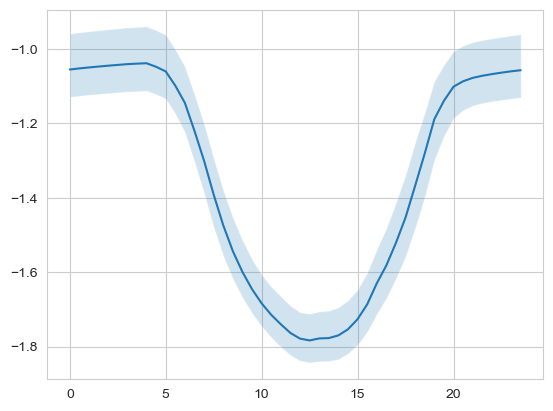

In [153]:
var = 'psiLeaf'
plt.plot(np.arange(0, 24, 0.5),dfm[var])
plt.fill_between(np.arange(0, 24, 0.5), dfql[var],dfqu[var], alpha=0.2)

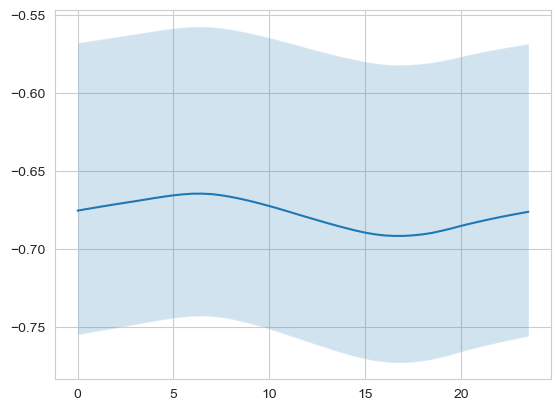

In [150]:
var = 'psiStem'
plt.plot(np.arange(0, 24, 0.5),dfm[var])
plt.fill_between(np.arange(0, 24, 0.5), dfql[var],dfqu[var], alpha=0.2)

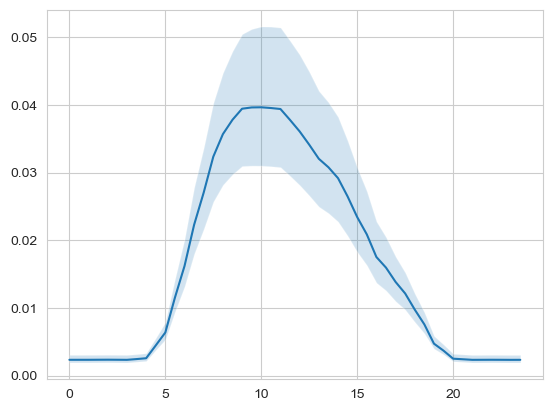

In [121]:
plt.plot(np.arange(0, 24, 0.5),dfm['gss'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['gss'],dfqu['gss'], alpha=0.2)

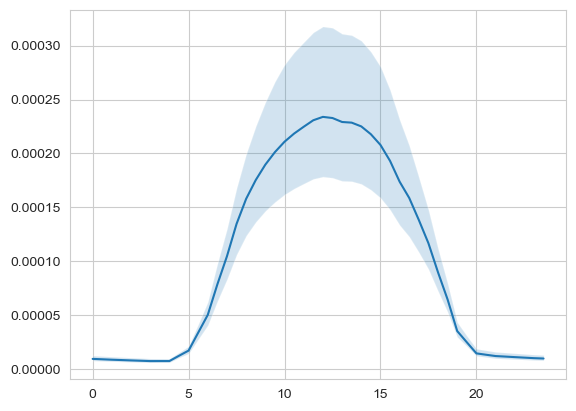

In [126]:
plt.plot(np.arange(0, 24, 0.5),dfm['T'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['T'],dfqu['T'], alpha=0.2)

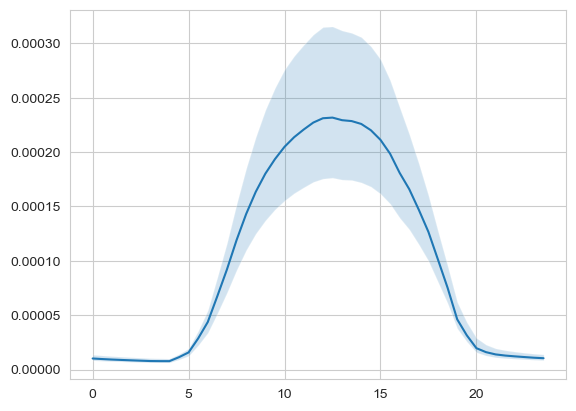

In [128]:
plt.plot(np.arange(0, 24, 0.5),dfm['J'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['J'],dfqu['J'], alpha=0.2)

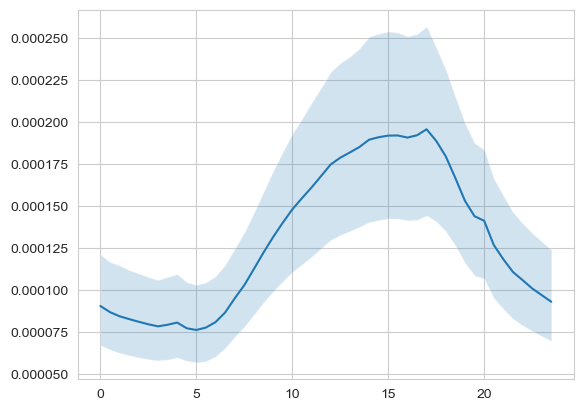

In [127]:
plt.plot(np.arange(0, 24, 0.5),dfm['G'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['G'],dfqu['G'], alpha=0.2)

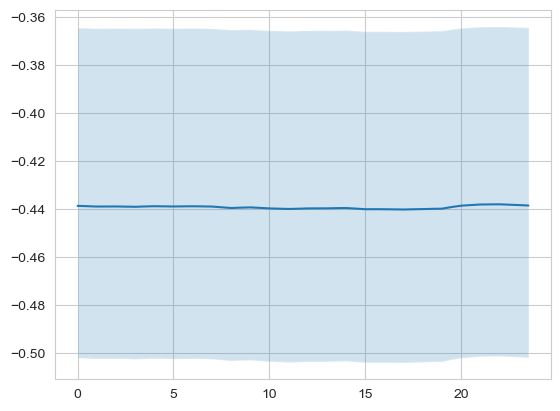

In [125]:
plt.fill_between(np.arange(0, 24, 0.5), dfql['psiSoilUp'], dfqu['psiSoilUp'], alpha=0.2)
plt.plot(np.arange(0, 24, 0.5), dfm['psiSoilUp'])


In [30]:
for i in [2,4,5]:
    print(np.round(df_ax_ql[i]['rmse'].iloc[0],2))
    print(np.round(df_ax_m[i]['rmse'].iloc[0],2))
    print(np.round(df_ax_qu[i]['rmse'].iloc[0],2))
    print("")

0.52
0.53
0.54

1.17
1.2
1.22

0.79
0.82
0.83



(-7.0, 0.0)

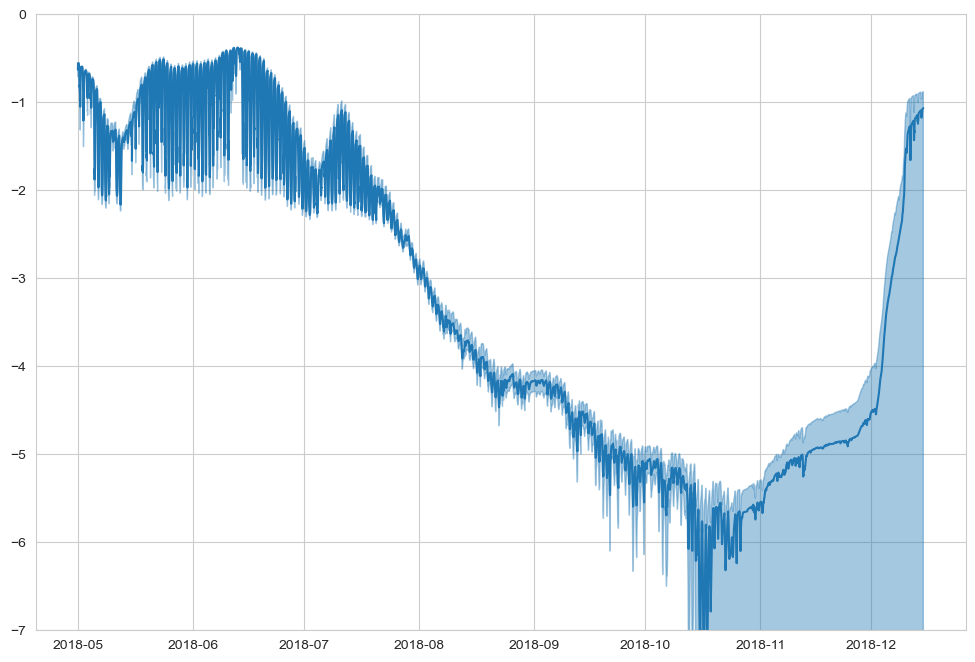

In [12]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(1,1, 1)
ax.plot(df_ax_m[2]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[2].index, df_ax_ql[2]['psiLeaf'], df_ax_qu[2]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ax.set_ylim(-7.0, 0)

In [6]:
plt.rcParams["font.family"] = "Avenir"

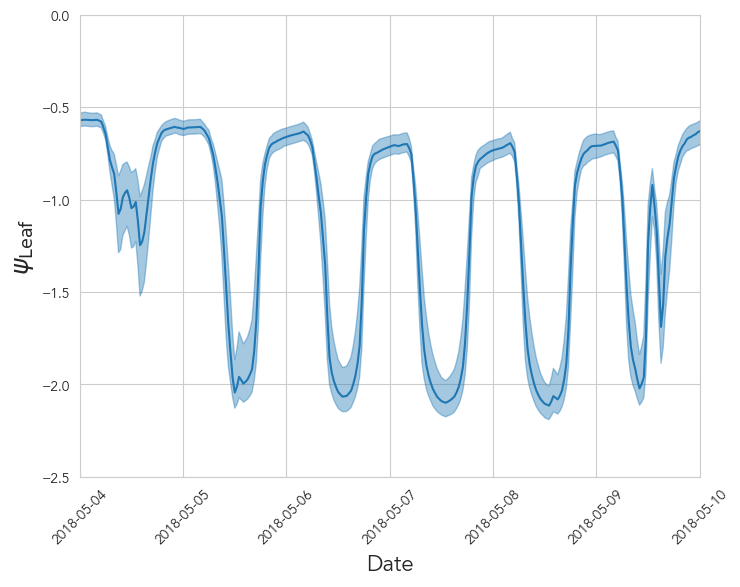

In [7]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-04'), pd.Timestamp('2018-05-10'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize = 18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P1.png"), bbox_inches='tight', dpi = 300)

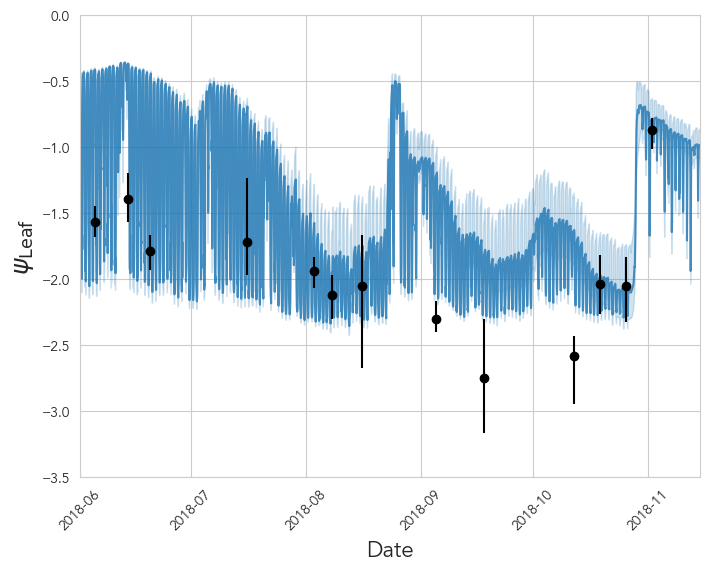

In [8]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:blue' ,alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:blue',
                alpha=0.2)
df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
df_tree_lower = trees[ii].groupby(trees[ii].index).min()
df_tree_upper = trees[ii].groupby(trees[ii].index).max()
ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                                       df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-11-15'))
plt.xticks(rotation=45)
ax.set_ylim(-3.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.savefig(os.path.join(post_path, "F1_P2.png"), bbox_inches='tight', dpi=300)

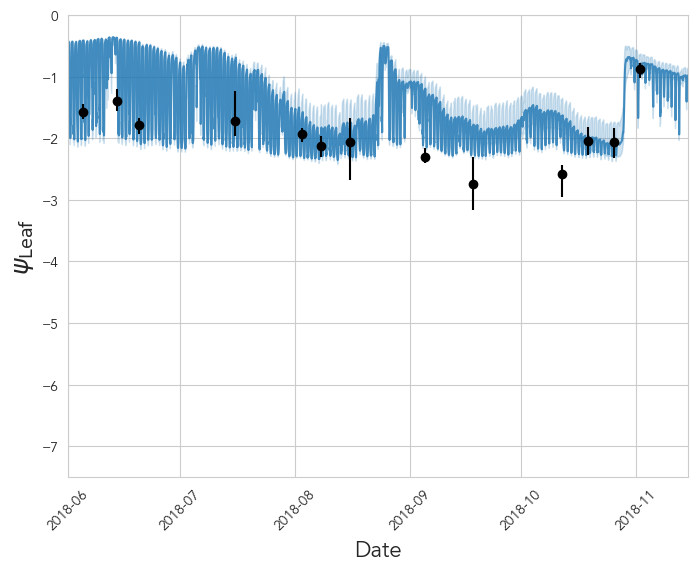

In [9]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:blue' ,alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:blue',
                alpha=0.2)
df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
df_tree_lower = trees[ii].groupby(trees[ii].index).min()
df_tree_upper = trees[ii].groupby(trees[ii].index).max()
ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                                       df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-11-15'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P3.png"), bbox_inches='tight', dpi=300)

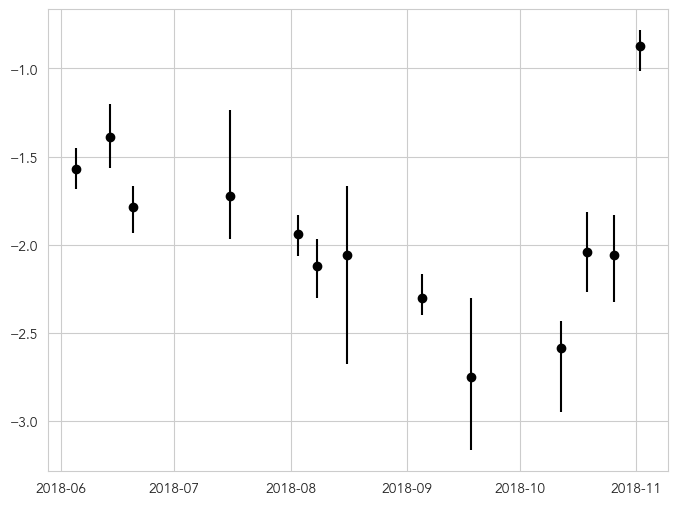

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
df_tree_lower = trees[ii].groupby(trees[ii].index).min()
df_tree_upper = trees[ii].groupby(trees[ii].index).max()
ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                                       df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
plt.show()

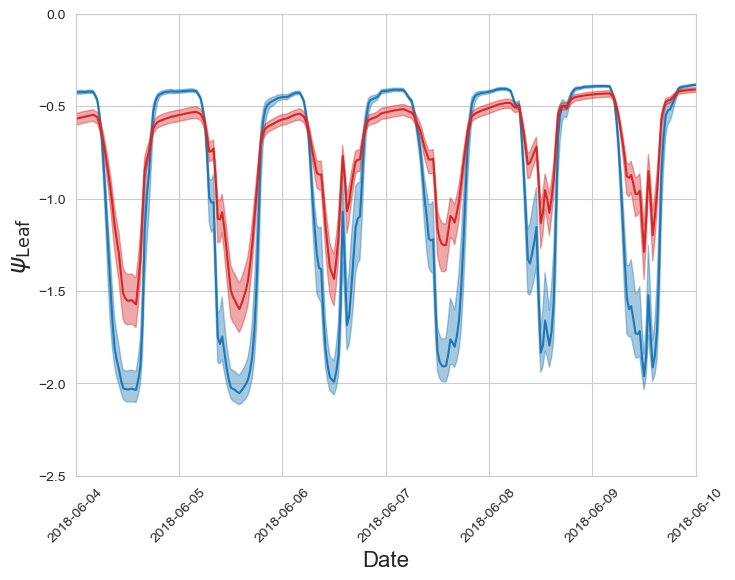

In [222]:

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ii = 2
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:red' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-06-04'), pd.Timestamp('2018-06-10'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P4.png"), bbox_inches='tight', dpi=300)

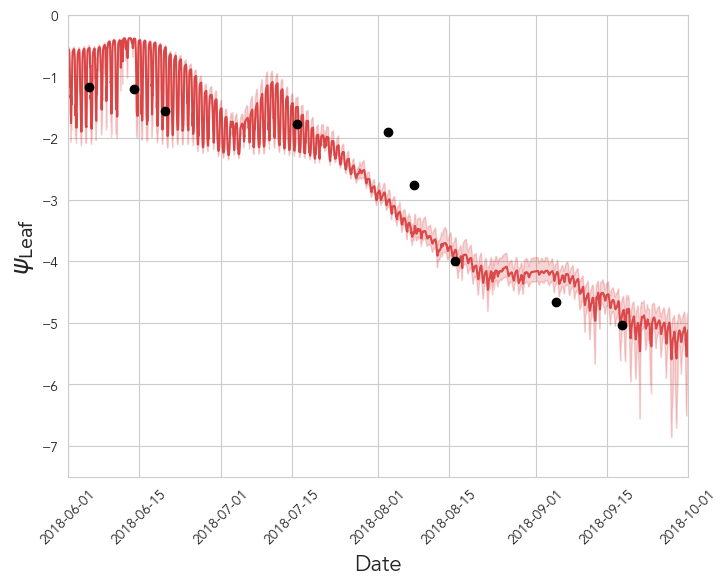

In [12]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P5.png"), bbox_inches='tight', dpi=300)

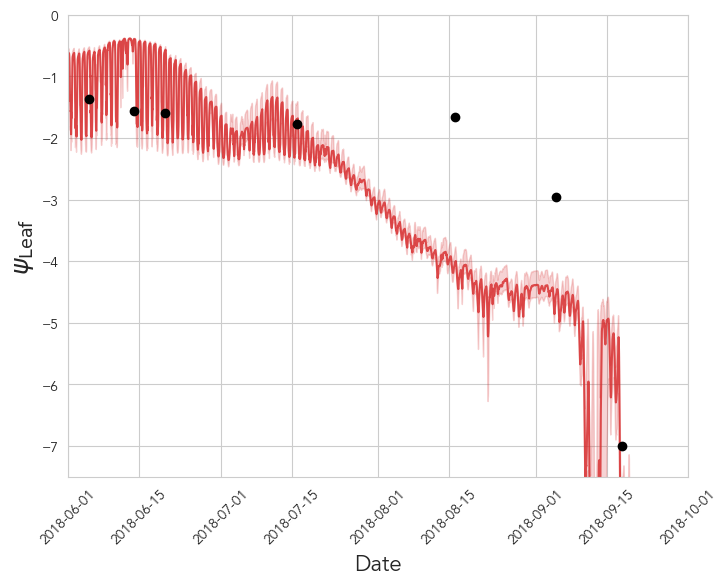

In [13]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 4
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P6.png"), bbox_inches='tight', dpi=300)

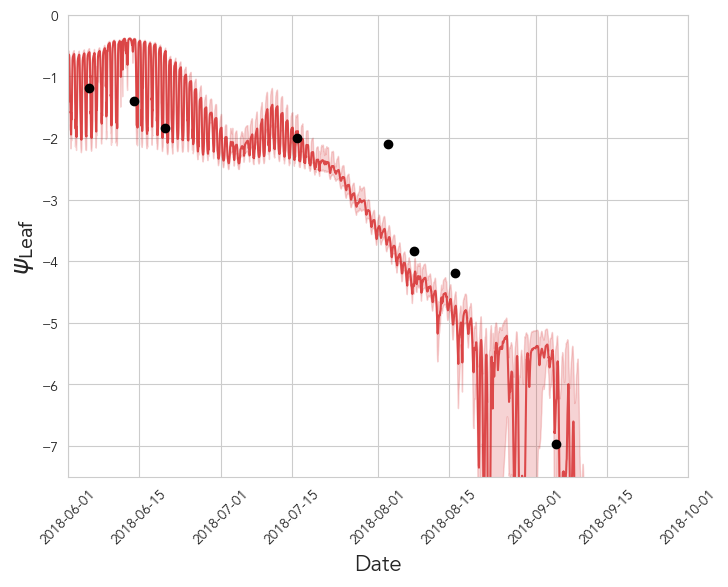

In [59]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P7.png"), bbox_inches='tight', dpi=300)

(-8.0, 0.0)

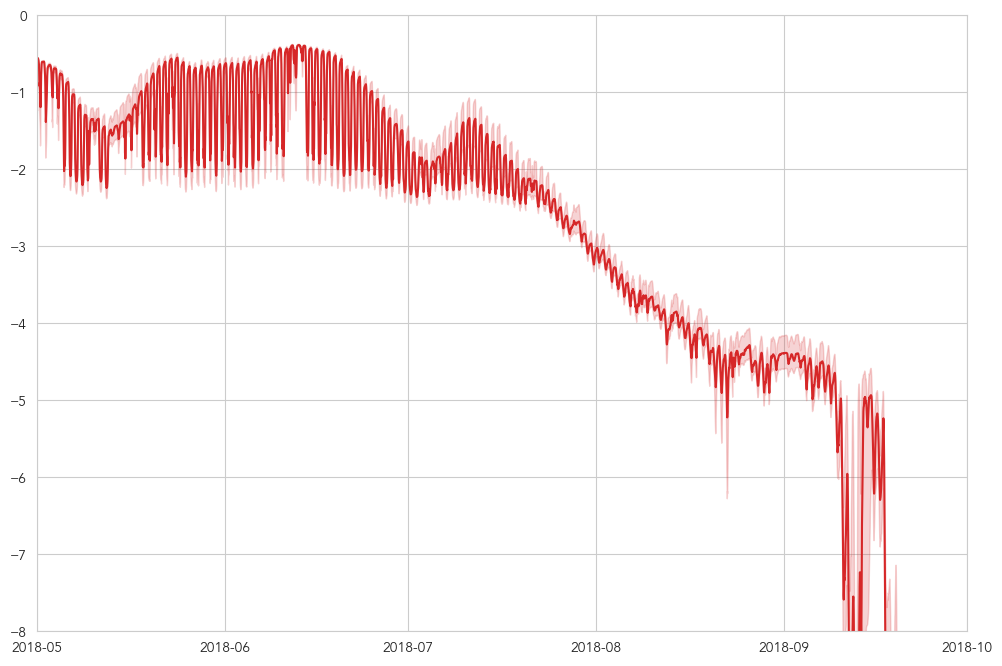

In [60]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(1,1, 1)
ii = 4
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:red' ,alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-8, 0)

(-8.0, 0.0)

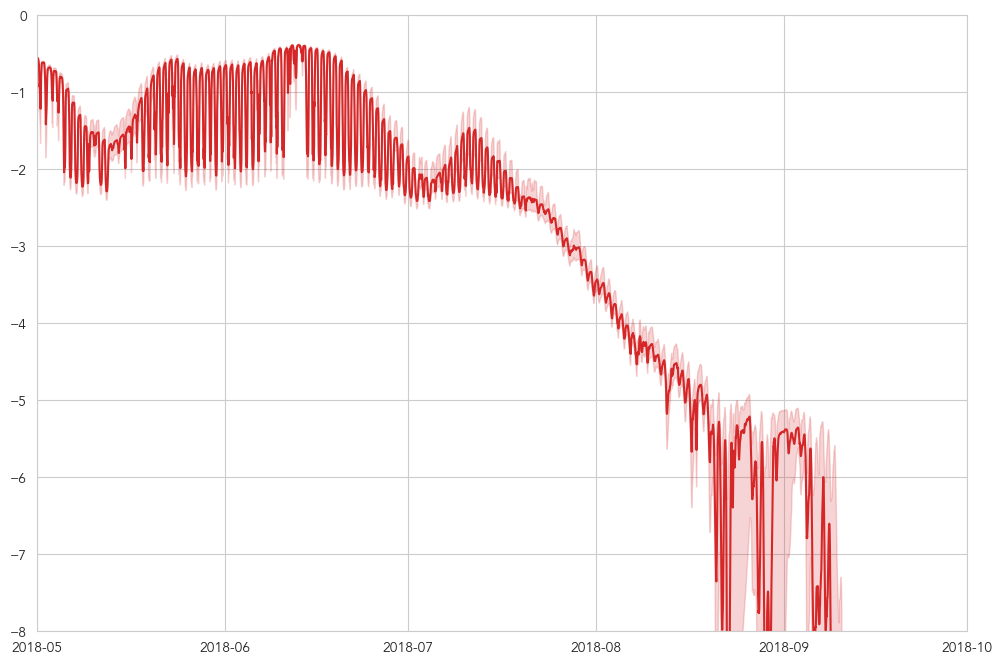

In [61]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(1,1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:red' ,alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-8, 0)

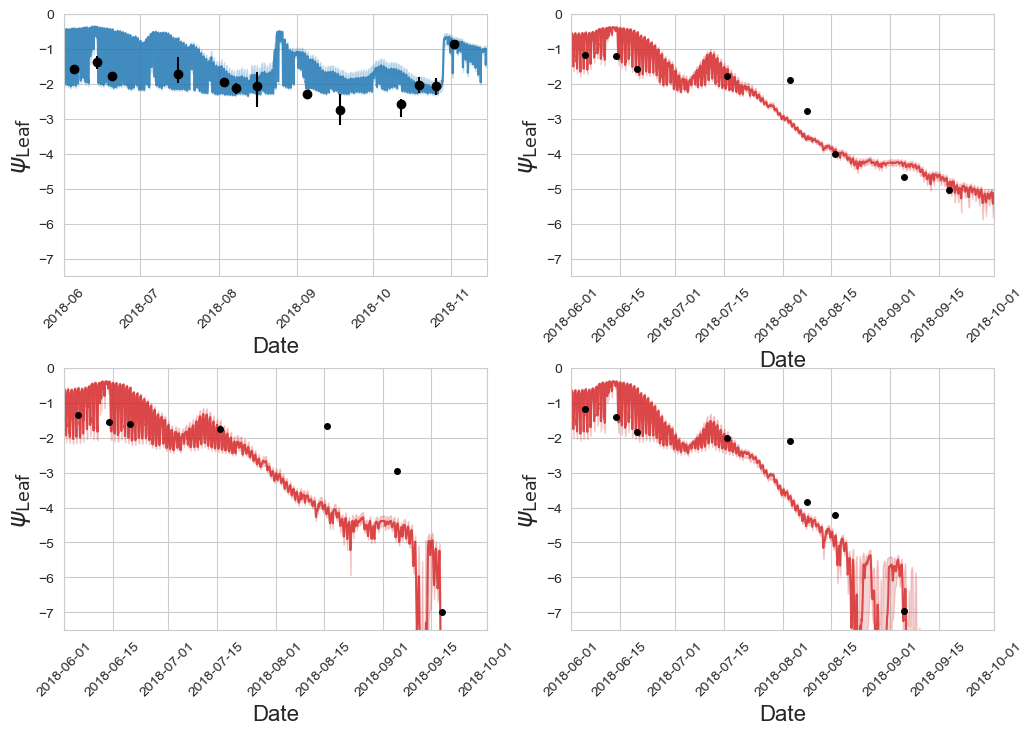

In [245]:
fig = plt.figure(figsize=(12, 8))


for i, ii in zip(range(1,5),[1,2,4,5]):
    if ii == 1:
        col = 'tab:blue'
    else:
        col = 'tab:red'
    ax = fig.add_subplot(2, 2, i)
    ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c=col, alpha=0.8)
    ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color=col,
                    alpha=0.2)
    if ii == 1:
        df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
        df_tree_lower = trees[ii].groupby(trees[ii].index).min()
        df_tree_upper = trees[ii].groupby(trees[ii].index).max()
        ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                        df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
    
    else:
        ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2, s =16)
    if ii == 1:
        ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-11-15'))
    else:
        ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
    ax.set_ylim(-7.5, 0)
    ax.set_xlabel("Date", fontsize=16)
    ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
    plt.xticks(rotation=45)
plt.subplots_adjust(hspace=0.35)
plt.savefig(os.path.join(post_path, "F1_ALL.png"), bbox_inches='tight', dpi=300)

(array([17655., 17656., 17657., 17658., 17659., 17660., 17661.]),
 [Text(17655.0, 0, '2018-05-04'),
  Text(17656.0, 0, '2018-05-05'),
  Text(17657.0, 0, '2018-05-06'),
  Text(17658.0, 0, '2018-05-07'),
  Text(17659.0, 0, '2018-05-08'),
  Text(17660.0, 0, '2018-05-09'),
  Text(17661.0, 0, '2018-05-10')])

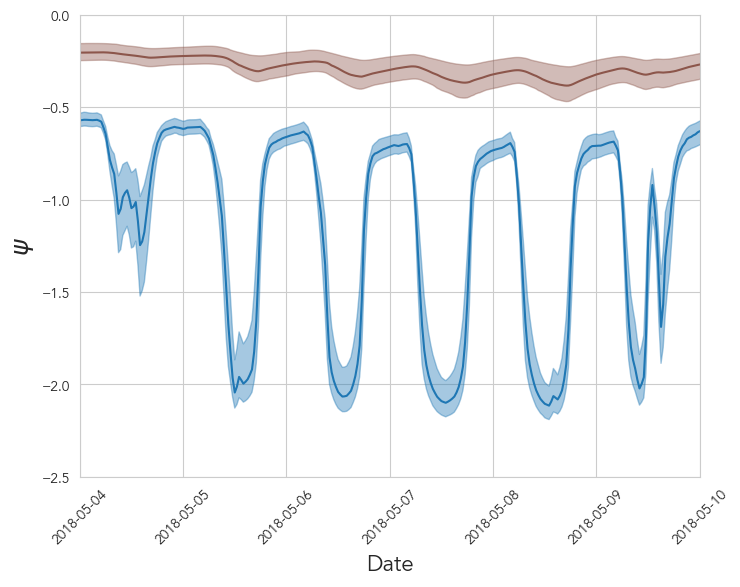

In [69]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ax.plot(df_ax_m[ii]['psiStem'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiStem'], df_ax_qu[ii]['psiStem'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-04'), pd.Timestamp('2018-05-10'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)
#plt.savefig(os.path.join(post_path, "F1_P1.png"), bbox_inches='tight', dpi = 300)

(-8.0, 0.0)

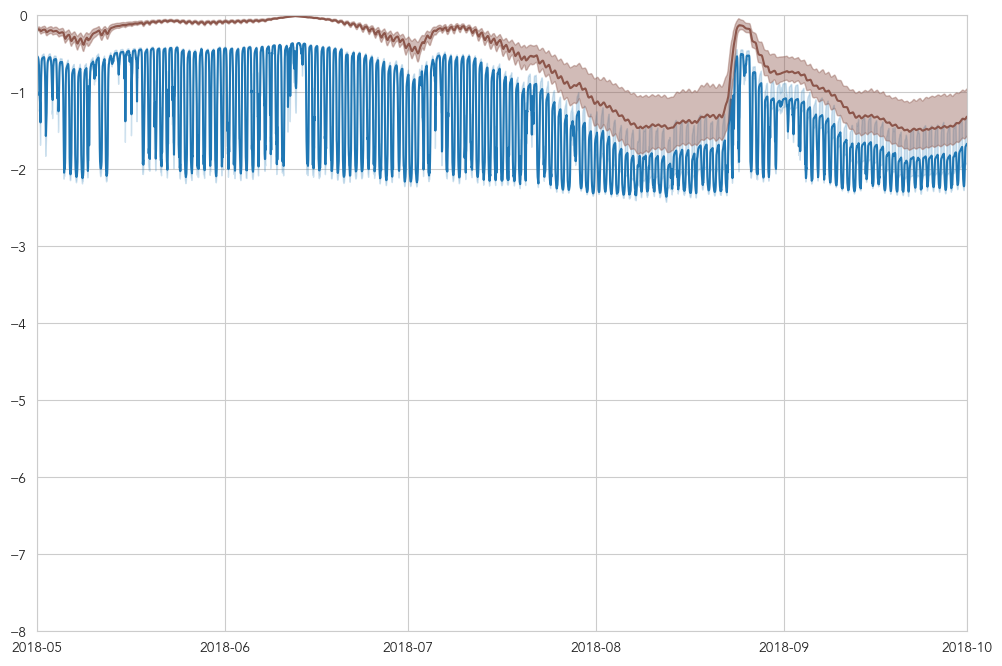

In [14]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:blue',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiStem'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiStem'], df_ax_qu[ii]['psiStem'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-8, 0)

(-10.0, 0.0)

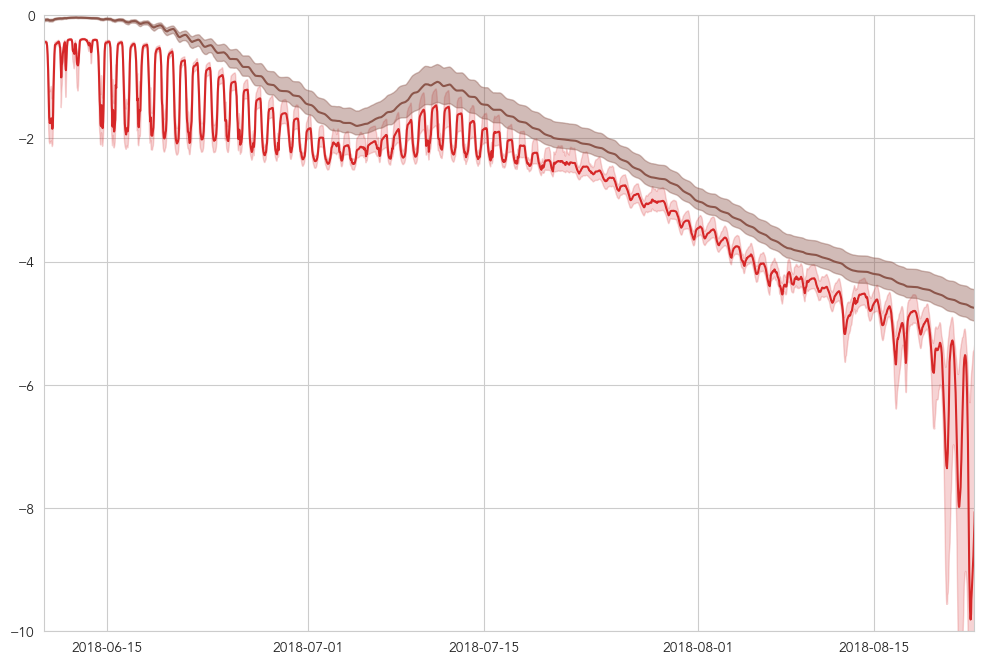

In [26]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiStem'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiStem'], df_ax_qu[ii]['psiStem'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-06-10'), pd.Timestamp('2018-8-23'))
ax.set_ylim(-10, 0)

(-10.0, 0.0)

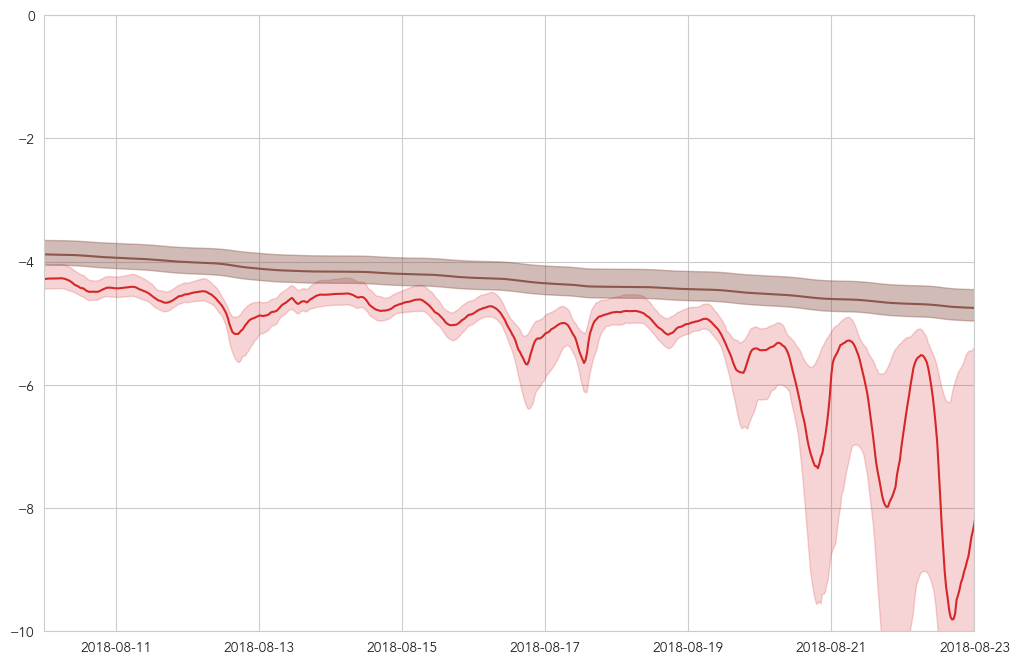

In [24]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiStem'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiStem'], df_ax_qu[ii]['psiStem'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-08-10'), pd.Timestamp('2018-8-23'))
ax.set_ylim(-10, 0)

(array([17720., 17727., 17734., 17744., 17751., 17758., 17765., 17775.,
        17782.]),
 [Text(17720.0, 0, '2018-07-08'),
  Text(17727.0, 0, '2018-07-15'),
  Text(17734.0, 0, '2018-07-22'),
  Text(17744.0, 0, '2018-08-01'),
  Text(17751.0, 0, '2018-08-08'),
  Text(17758.0, 0, '2018-08-15'),
  Text(17765.0, 0, '2018-08-22'),
  Text(17775.0, 0, '2018-09-01'),
  Text(17782.0, 0, '2018-09-08')])

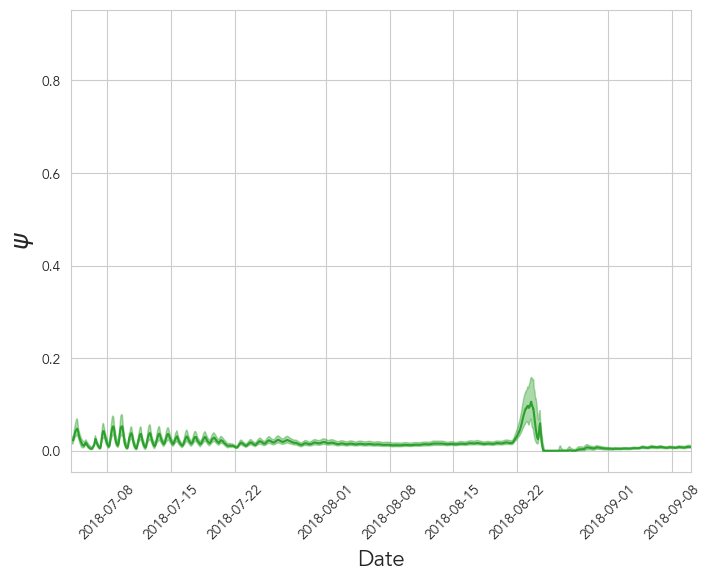

In [85]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['Gs'], zorder =1, c = 'tab:green')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['Gs'], df_ax_qu[ii]['Gs'], zorder = 1, color = 'tab:green' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-07-04'), pd.Timestamp('2018-09-10'))
#ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

(array([17652., 17666., 17683., 17697., 17713., 17727., 17744., 17758.,
        17775.]),
 [Text(17652.0, 0, '2018-05-01'),
  Text(17666.0, 0, '2018-05-15'),
  Text(17683.0, 0, '2018-06-01'),
  Text(17697.0, 0, '2018-06-15'),
  Text(17713.0, 0, '2018-07-01'),
  Text(17727.0, 0, '2018-07-15'),
  Text(17744.0, 0, '2018-08-01'),
  Text(17758.0, 0, '2018-08-15'),
  Text(17775.0, 0, '2018-09-01')])

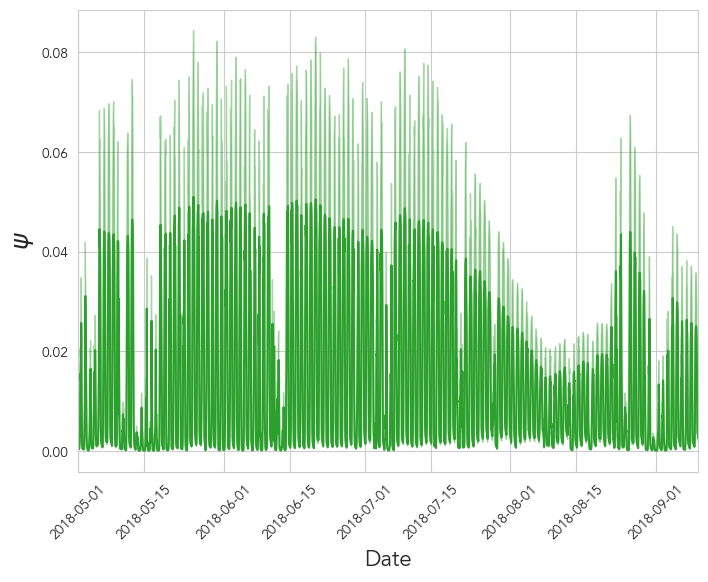

In [31]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['Js'], zorder =1, c = 'tab:green')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['Js'], df_ax_qu[ii]['Js'], zorder = 1, color = 'tab:green' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-09-10'))
#ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

(array([17666., 17668., 17670., 17672., 17674., 17676., 17678., 17680.,
        17682., 17683.]),
 [Text(17666.0, 0, '2018-05-15'),
  Text(17668.0, 0, '2018-05-17'),
  Text(17670.0, 0, '2018-05-19'),
  Text(17672.0, 0, '2018-05-21'),
  Text(17674.0, 0, '2018-05-23'),
  Text(17676.0, 0, '2018-05-25'),
  Text(17678.0, 0, '2018-05-27'),
  Text(17680.0, 0, '2018-05-29'),
  Text(17682.0, 0, '2018-05-31'),
  Text(17683.0, 0, '2018-06-01')])

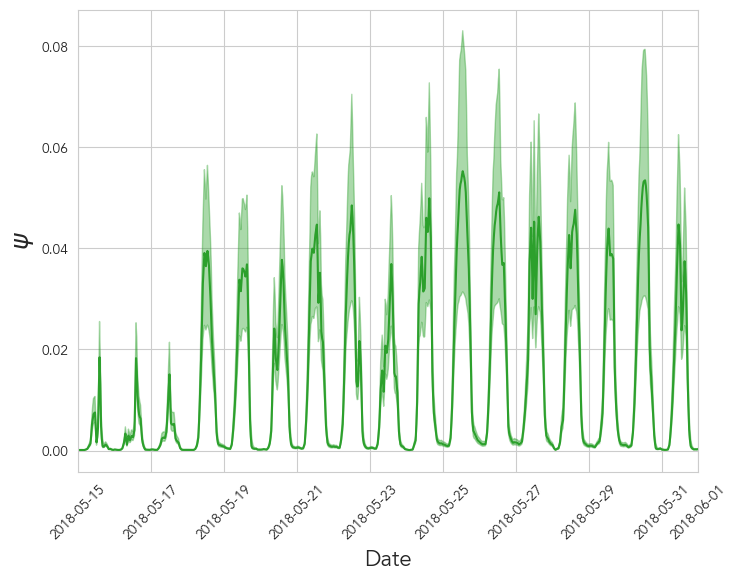

In [36]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 2
ax.plot(df_ax_m[ii]['Js'], zorder =1, c = 'tab:green')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['Js'], df_ax_qu[ii]['Js'], zorder = 1, color = 'tab:green' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-15'), pd.Timestamp('2018-06-1'))
#ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

In [35]:
0.06 * 100/1000*18*1000

108.0

(-10.0, 0.0)

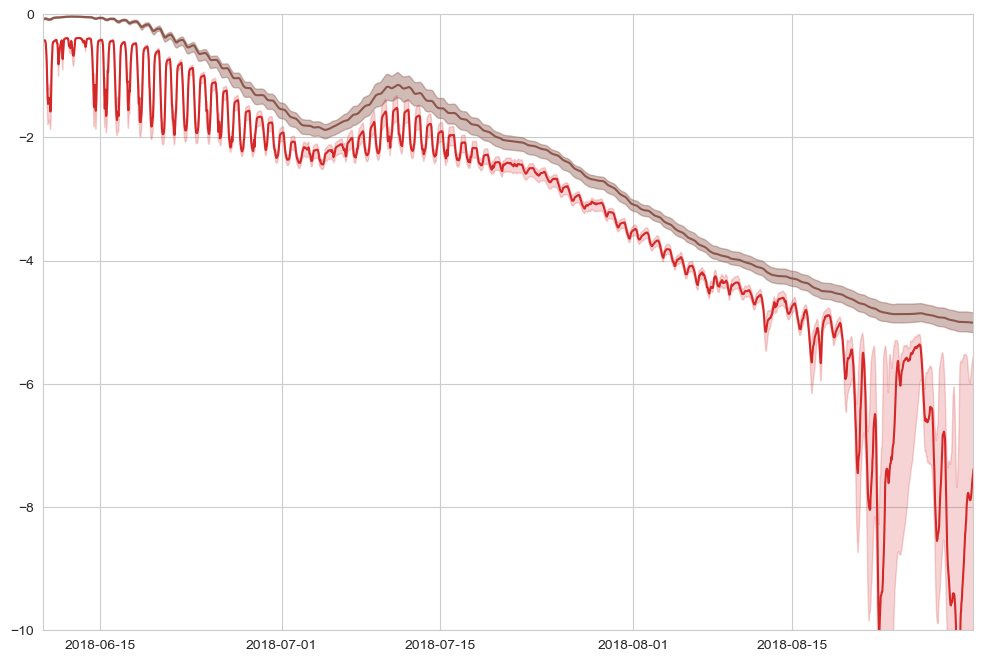

In [215]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiStem'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiStem'], df_ax_qu[ii]['psiStem'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-06-10'), pd.Timestamp('2018-8-31'))
ax.set_ylim(-10, 0)

(17727.0, 17774.0)

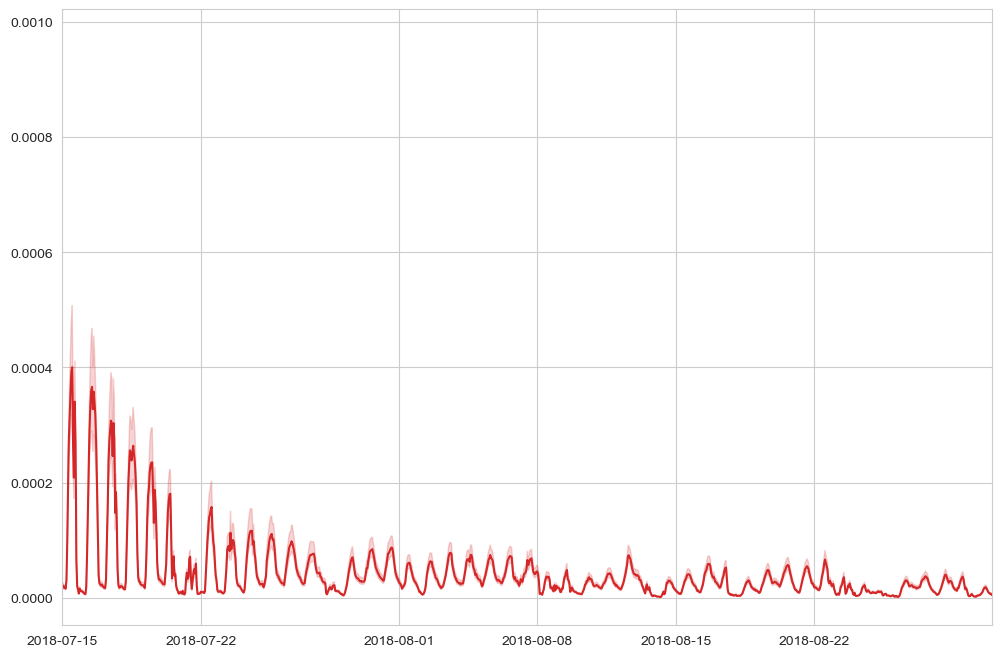

In [19]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['T'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['T'], df_ax_qu[ii]['T'], zorder=1, color='tab:red',
                alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-07-15'), pd.Timestamp('2018-8-31'))

(17727.0, 17774.0)

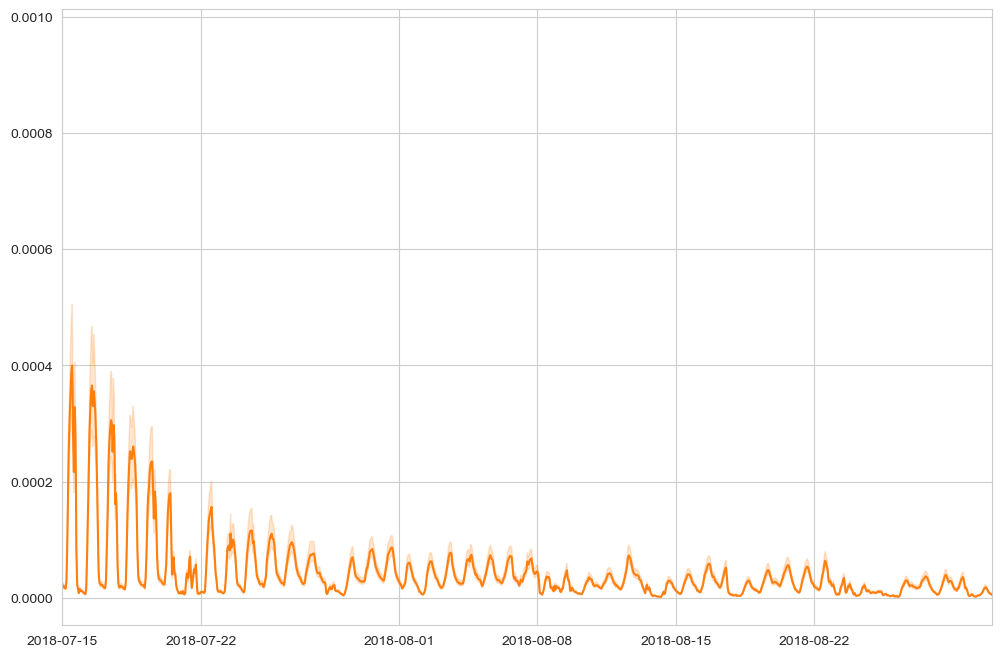

In [22]:
ax.set_ylim(-10, 0)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['J'], zorder=1, c='tab:orange')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['J'], df_ax_qu[ii]['J'], zorder=1, color='tab:orange',
                alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-07-15'), pd.Timestamp('2018-8-31'))

(17727.0, 17774.0)

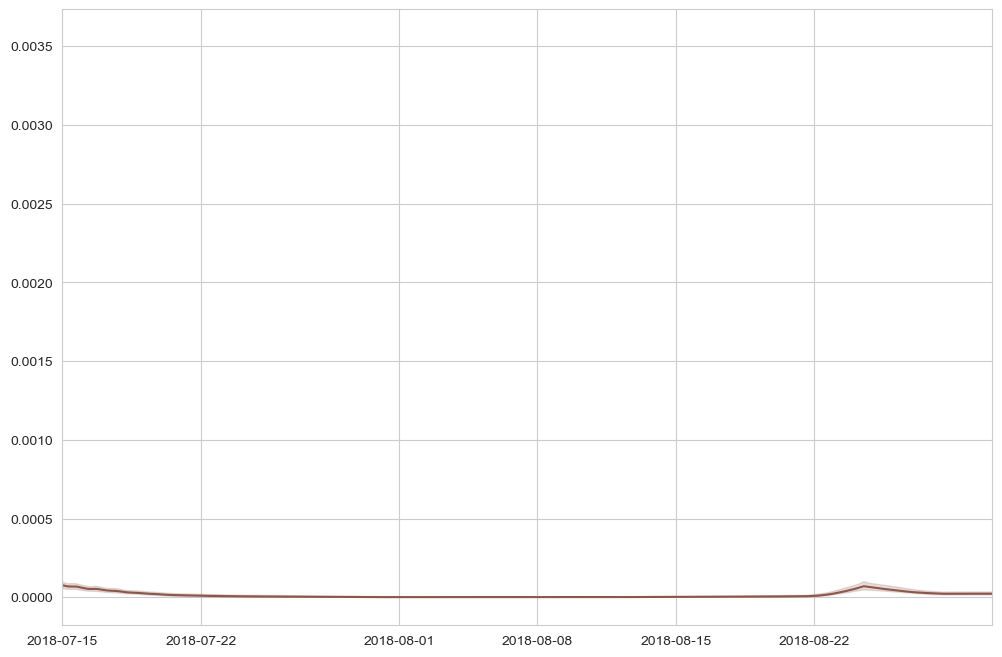

In [27]:
ax.set_ylim(-10, 0)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['G'], zorder=1, c='tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['G'], df_ax_qu[ii]['G'], zorder=1, color='tab:brown',
                alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-07-15'), pd.Timestamp('2018-8-31'))

In [165]:
df_ax_m[ii]['T'].mean()

4.9774842025871535e-05

In [168]:
df_ax_m[ii]['T']['2018-07-15':'2018-08-15'].mean()

4.363975051480118e-05

In [201]:
ii=2
df_ax_m[ii]['vpd']['2018-08-1':'2018-09-01'].mean()

1000.6303757727146

In [202]:
ii = 2
df_ax_m[ii]['gss']['2018-08-01':'2018-09-01'].mean()

0.0024872786598280072

In [203]:
ii = 2
df_ax_m[ii]['T']['2018-08-01':'2018-09-01'].mean()

2.456906775842131e-05

In [204]:
ii = 2
df_ax_m[ii]['gss']['2018-08-01':'2018-09-01'].mean()

0.0024872786598280072

In [205]:
ii = 2
df_ax_m[ii]['psiLeaf']['2018-08-01'].min()-df_ax_m[ii]['psiLeaf']['2018-09-01'].min()

1.2486491203308105

In [206]:
1.2486491203308105 / 31

0.04027900388163905

In [216]:
ii = 5
df_ax_m[ii]['psiLeaf']['2018-08-01'].min() - df_ax_m[ii]['psiLeaf']['2018-08-15'].min()

1.455795168876648

In [217]:
1.455795168876648/15

0.09705301125844319

In [218]:
ii=2
df_ax_m[ii]['vpd']['2018-08-1':'2018-08-15'].mean()

1280.0490270879534